# Explanation with SHAP

## Load model

In [31]:
import joblib
import pandas as pd
import shap
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap
import numpy as np

BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

In [32]:
pipeline = joblib.load(f'../saved-models/{pfs_dir}/best_pipeline{rna_suffix}.joblib')
x_train = pd.read_csv(f"../dataset/created/{pfs_dir}/x_train{rna_suffix}.csv")
x_test = pd.read_csv(f"../dataset/created/{pfs_dir}/x_test{rna_suffix}.csv")
y_train = pd.read_csv(f"../dataset/created/{pfs_dir}/y_train{rna_suffix}.csv").squeeze()
y_test = pd.read_csv(f"../dataset/created/{pfs_dir}/y_test{rna_suffix}.csv").squeeze()

x = pd.concat([x_train, x_test])
y = pd.concat([y_train, y_test])


              precision    recall  f1-score   support

  Short resp       1.00      0.91      0.96        47
   Long resp       0.89      1.00      0.94        31

    accuracy                           0.95        78
   macro avg       0.94      0.96      0.95        78
weighted avg       0.95      0.95      0.95        78



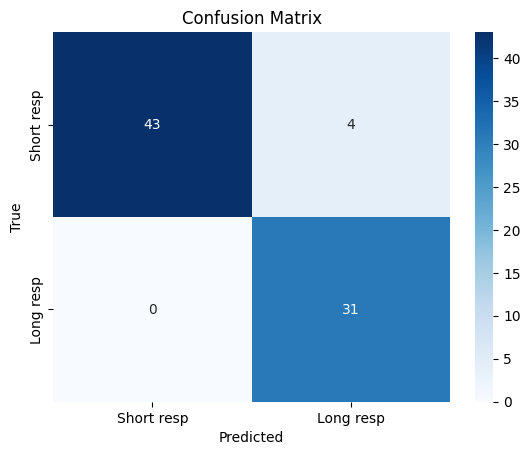

In [33]:
target_names = ['Short resp', 'Long resp']

y_pred = pipeline.predict(x)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Calculated SHAP values

In [34]:
model = pipeline[-1]

x_train_scaled = pipeline[:-1].transform(x_train)   # x -> preprocessed -> scaler
x_scaled = pipeline[:-1].transform(x)

preprocessed_feature_names = pipeline['preprocess'].get_feature_names_out()
feature_names = [
    n.replace('remainder__', '')
     .replace('m_stage__', '')
     .replace('categorical__', '')
     .replace('sex__', '')
     .replace('age__', '')
     .replace('drug_braf__', '')
    for n in pipeline['preprocess'].get_feature_names_out()
]

explainer = shap.LinearExplainer(model, x_train_scaled)   # pass only Train as background
shap_values = explainer(x_scaled)                         # explain both Train+Test
shap_values.feature_names = feature_names

## Plot explanation

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


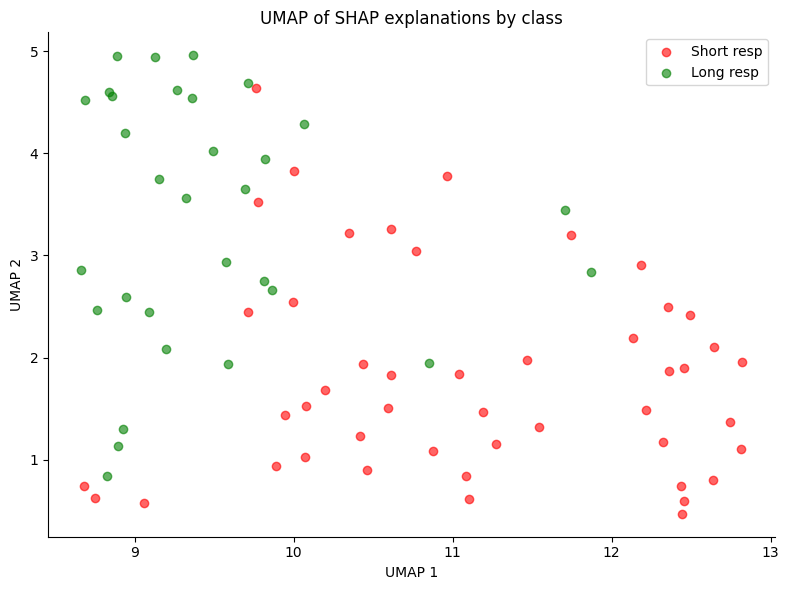

In [35]:
def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    if BINARY_PFS:
        colors = {0: "red", 1: "green"}
        labels = {0: "Short resp", 1: "Long resp"}
    else:
        colors = {0: "red", 1: "orange", 2: "green"}
        labels = {0: "Short resp", 1: "Intermediate", 2: "Long resp"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

# For multiclass SHAP, values are (n_samples, n_features, n_classes) — flatten to 2D
if BINARY_PFS:
    sv_input = shap_values.values                              # already (n_samples, n_features)
else:
    sv_input = shap_values.values.reshape(len(y_arr), -1)     # (n_samples, n_features * n_classes)

# # PCA — pass explained variance
# pca = PCA(n_components=2)
# sv_2d = pca.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# # t-SNE
# tsne = TSNE(n_components=2, perplexity=20, random_state=42)
# sv_2d = tsne.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# UMAP
u_map = umap.UMAP(n_components=2, random_state=42)
sv_2d = u_map.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# # PaCMAP
# pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
# sv_2d = pac_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")


## Global interpretability

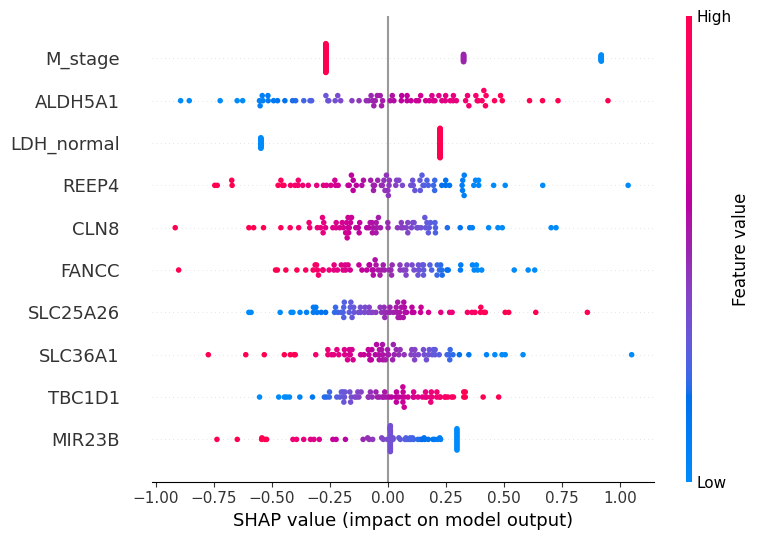

In [36]:
shap.summary_plot(shap_values, x_scaled, feature_names=feature_names, max_display=10)

In [37]:
# for cls, label in [(0, "Short resp"), (1, "Long resp")]:
#     mask = y_pred == cls
#     shap.summary_plot(
#         shap_values[mask],
#         x_scaled[mask],
#         feature_names=feature_names,
#         max_display=10,
#         show=False,
#     )
#     plt.title(f"predicted {label} (n={mask.sum()})")
#     plt.tight_layout()
#     plt.show()

## Count FP, FN .. and their log-odds

In [38]:
y_pred = model.predict(x_scaled)
misclassified = np.where(y_pred != y)[0]
print(f"Misclassified indices: {misclassified}\n")

fp = np.where((y == 0) & (y_pred == 1))[0]  # misclassified short
fn = np.where((y == 1) & (y_pred == 0))[0]  # misclassified long
tn = np.where((y == 0) & (y_pred == 0))[0]   # correctly predicted short
tp = np.where((y == 1) & (y_pred == 1))[0]   # correctly predicted long
print(f'FP (misclassified short): {fp}')
print(f'FN (misclassified long): {fn}')
print(f'TN (correct short): {tn}')
print(f'TP (correct long): {tp}')

Misclassified indices: [ 0 13 33 67]

FP (misclassified short): [ 0 13 33 67]
FN (misclassified long): []
TN (correct short): [ 3  4  5  6  8 11 12 15 17 18 21 28 29 31 32 34 35 36 37 38 39 40 41 42
 43 46 47 51 53 54 56 58 60 61 62 65 66 68 69 72 75 76 77]
TP (correct long): [ 1  2  7  9 10 14 16 19 20 22 23 24 25 26 27 30 44 45 48 49 50 52 55 57
 59 63 64 70 71 73 74]


In [39]:
log_odds = model.decision_function(x_scaled)

print(f'FP log-odds: {log_odds[fp]}')
print(f'FN log-odds: {log_odds[fn]}')
print(f'TN log-odds: {log_odds[tn]}')
print(f'TP log-odds: {log_odds[tp]}')

FP log-odds: [0.01638608 0.17785049 1.39388316 0.37250674]
FN log-odds: []
TN log-odds: [-1.27114169 -3.25459533 -3.49236493 -1.26687747 -1.45165312 -1.0980495
 -2.06275948 -4.43478405 -0.65791322 -4.71000469 -0.50078758 -2.0508866
 -1.42761631 -2.02414322 -1.4890376  -2.47929482 -3.48878855 -3.18176621
 -1.66334953 -2.11583648 -3.10537697 -3.25214617 -3.66708132 -4.16111302
 -1.32533585 -1.56997878 -3.1188986  -1.70201605 -3.584695   -2.08231912
 -1.7384729  -0.70150915 -0.55958551 -1.8215907  -2.31507631 -3.63919516
 -1.0528055  -3.54613499 -1.47737731 -1.80233964 -1.52047858 -2.78956523
 -2.72884489]
TP log-odds: [3.12676831 1.65213287 1.73760323 4.61748902 1.85030423 1.40265304
 1.65949011 0.62666577 1.35707519 0.5597821  3.50936438 0.35359717
 1.78718679 2.07267043 0.45303752 0.04940573 0.94611237 1.48291159
 4.38146719 1.46446901 2.79855503 4.03731945 3.69757024 1.16124287
 3.51331881 3.82551075 1.35027281 0.27939263 2.02892924 1.26288041
 1.64041739]


## Local interpretability

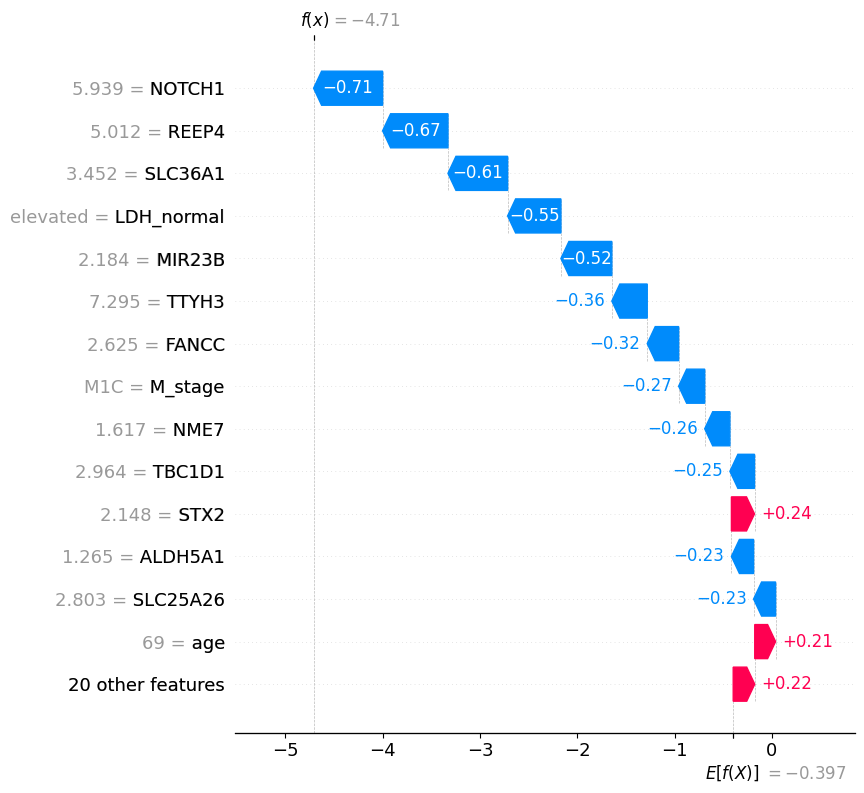

In [40]:
import copy
sv_raw = copy.copy(shap_values)
sv_raw.data = x.values

shap.plots.waterfall(sv_raw[tn[9]], max_display=15)

In [41]:
shap.initjs()
shap.plots.force(sv_raw[tn[35]]) # 9 7 23 35

In [42]:
shap.plots.force(sv_raw[tp[25]]) # 3 18 21 25

## Subgroups analysis: Kmeans

In [43]:
def plot_umap_clusters(cluster_labels, n_clusters, title):
    
    cluster_colors = plt.cm.tab10.colors[:n_clusters]
    markers = {0: "o", 1: "^"}  # circle=short resp, triangle=long resp

    fig, ax = plt.subplots(figsize=(8, 6))

    for k in range(n_clusters):
        for cls in np.unique(y_arr):
            mask = (cluster_labels == k) & (y_arr == cls)
            label = f"Cluster {k} – {'Short resp' if cls == 0 else 'Long resp'}"
            ax.scatter(
                sv_2d[mask, 0], sv_2d[mask, 1],
                c=[cluster_colors[k]], marker=markers[cls],
                alpha=0.7, label=label, edgecolors="k", linewidths=0.4,
            )

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    
def count_samples_each_cluster(cluster_labels, n_clusters):
    for k in range(n_clusters):
        mask = cluster_labels == k
        counts = pd.Series(y_arr[mask]).value_counts().sort_index()
        short = counts.get(0, 0)
        long  = counts.get(1, 0)
        print(f"Cluster {k}: {short} Short resp, {long} Long resp")
        
def plot_heatmap_clusters(sv_df, cluster_labels, top_k, title, subset_clusters=None):
    
    sv_df["cluster"] = cluster_labels
    cluster_means = sv_df.groupby("cluster").mean()
    fig_height = 4
    
    if subset_clusters is not None:
        cluster_means = cluster_means.loc[subset_clusters]
        fig_height = 3

    # keep top 20 features with highest variance across clusters
    top_features = cluster_means.std(axis=0).nlargest(top_k).index
    heatmap_data = cluster_means[top_features]

    fig, ax = plt.subplots(figsize=(14, fig_height))
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm", center=0,
        annot=True, fmt=".2f",
        linewidths=0.4, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Cluster")
    plt.xticks()
    plt.tight_layout()
    plt.show()


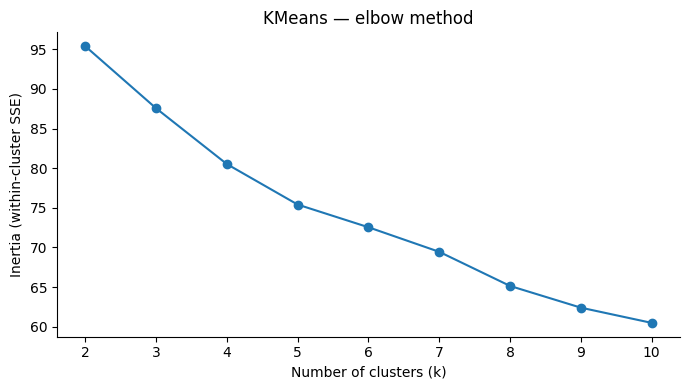

In [44]:
from sklearn.cluster import KMeans

# KMeans elbow
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sv_input)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster SSE)")
ax.set_title("KMeans — elbow method")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

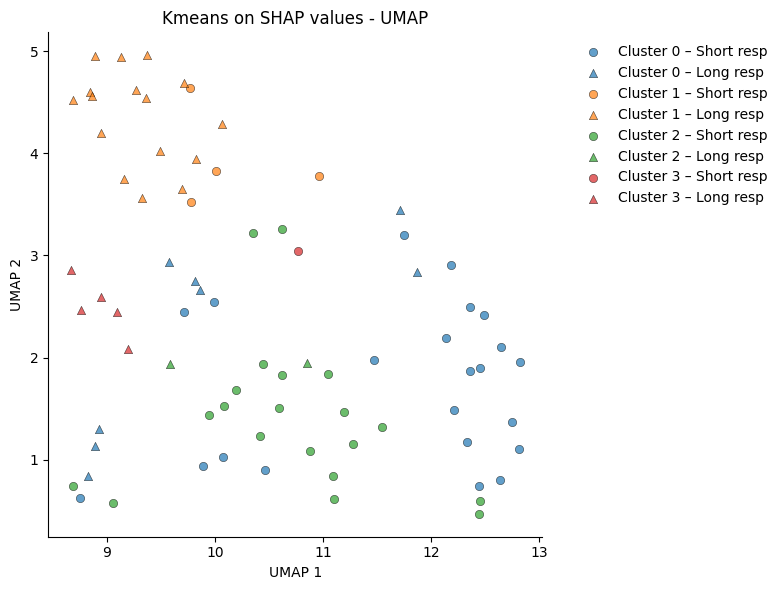

Cluster 0: 22 Short resp, 8 Long resp
Cluster 1: 4 Short resp, 16 Long resp
Cluster 2: 20 Short resp, 2 Long resp
Cluster 3: 1 Short resp, 5 Long resp


In [45]:
from sklearn.cluster import KMeans

n_clusters = 4

# cluster in full SHAP space
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_kmeans = kmeans.fit_predict(sv_input)

# use sv_2d only for visualization
plot_umap_clusters(cluster_labels_kmeans, n_clusters, 'Kmeans on SHAP values - UMAP')

count_samples_each_cluster(cluster_labels_kmeans, n_clusters)


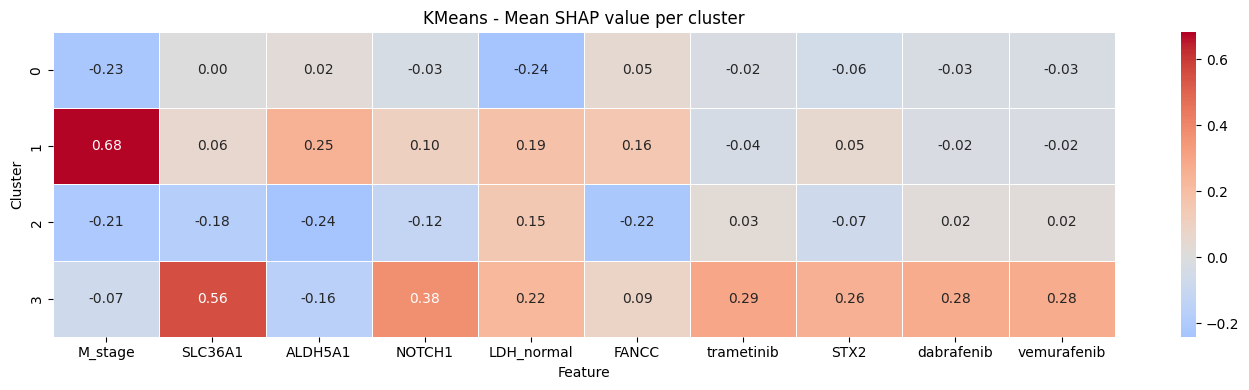

In [46]:
sv_df = pd.DataFrame(shap_values.values, columns=feature_names)

plot_heatmap_clusters(sv_df, cluster_labels_kmeans, top_k=10, title='KMeans - Mean SHAP value per cluster')

## Subgroups analysis: Hierarchical clustering

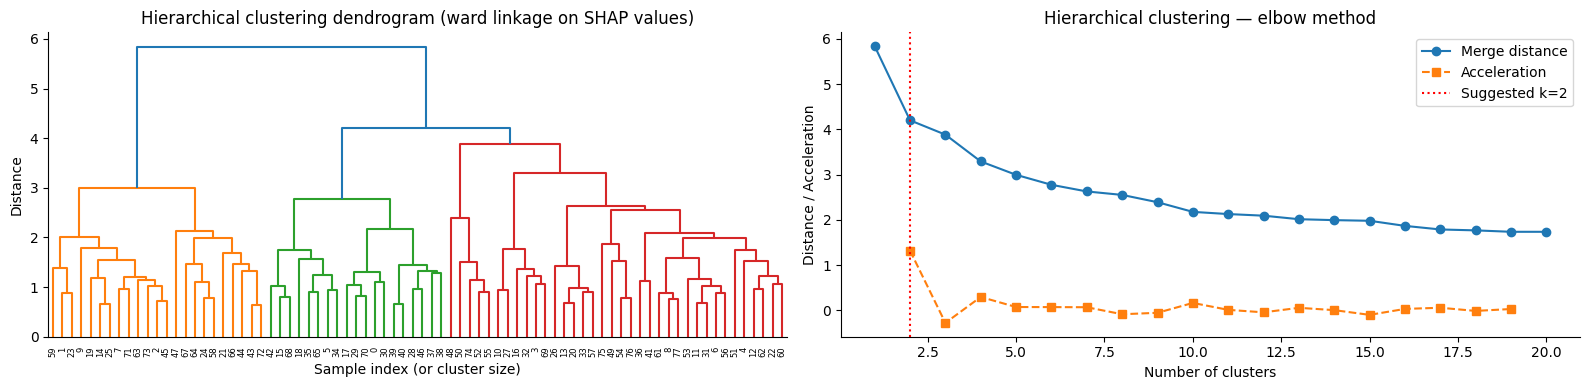

Suggested number of clusters (hierarchical): 2


In [47]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(sv_input, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Dendrogram
dendrogram(Z, ax=axes[0])
axes[0].set_title("Hierarchical clustering dendrogram (ward linkage on SHAP values)")
axes[0].set_xlabel("Sample index (or cluster size)")
axes[0].set_ylabel("Distance")
axes[0].spines[["top", "right"]].set_visible(False)

# Elbow: last merge distances and their acceleration
last = Z[-20:, 2][::-1]          # top 20 merge distances, largest first
acceleration = np.diff(last, 2)   # second derivative — peak = elbow
suggested_k = int(acceleration.argmax()) + 2
idxs = np.arange(1, len(last) + 1)

axes[1].plot(idxs, last, marker="o", label="Merge distance")
axes[1].plot(idxs[1:-1], acceleration, marker="s", linestyle="--", label="Acceleration")
axes[1].axvline(x=suggested_k, color="red", linestyle=":", label=f"Suggested k={suggested_k}")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Distance / Acceleration")
axes[1].set_title("Hierarchical clustering — elbow method")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Suggested number of clusters (hierarchical): {suggested_k}")

Number of clusters at threshold 3.8: 4


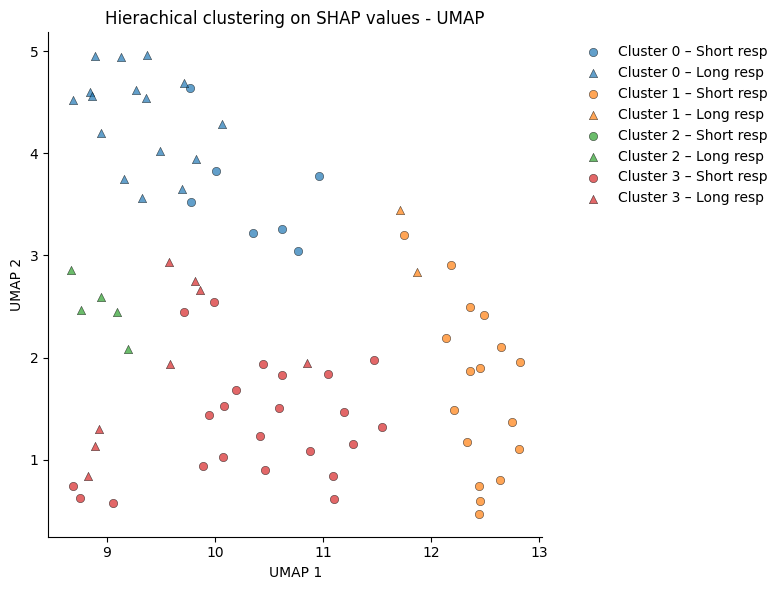

Cluster 0: 7 Short resp, 16 Long resp
Cluster 1: 17 Short resp, 2 Long resp
Cluster 2: 0 Short resp, 5 Long resp
Cluster 3: 23 Short resp, 8 Long resp


In [48]:
dist_threshold = 3.8   # adjust based on dendrogram
cluster_labels_hier = fcluster(Z, t=dist_threshold, criterion="distance") - 1  # 0-indexed
n_clusters_hier = cluster_labels_hier.max() + 1
print(f"Number of clusters at threshold {dist_threshold}: {n_clusters_hier}")

# use sv_2d only for visualization
plot_umap_clusters(cluster_labels_hier, n_clusters_hier, 'Hierachical clustering on SHAP values - UMAP')

count_samples_each_cluster(cluster_labels_hier, n_clusters_hier)

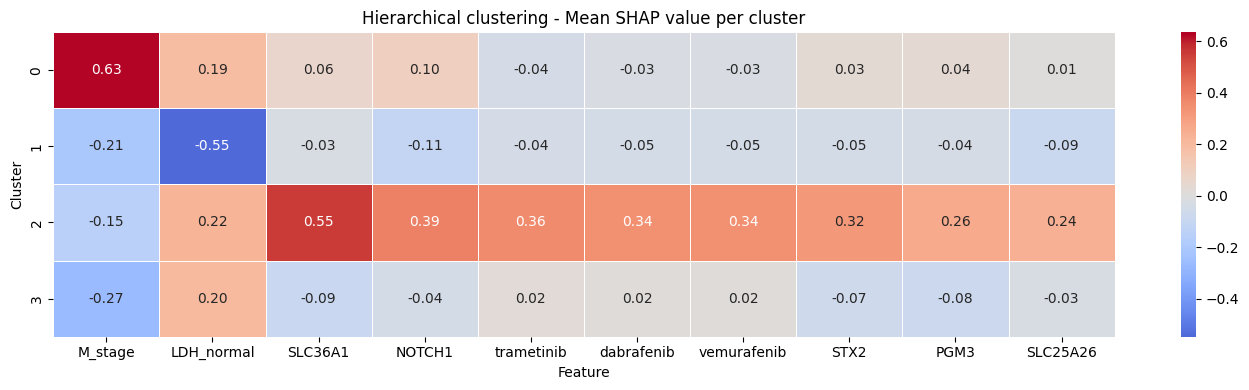

In [49]:
plot_heatmap_clusters(sv_df, cluster_labels_hier, top_k=10, title='Hierarchical clustering - Mean SHAP value per cluster')

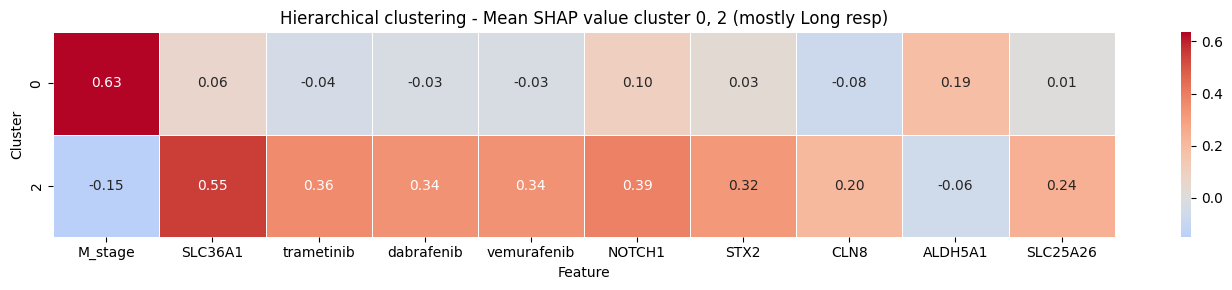

In [50]:
subset_clusters = [0, 2]

plot_heatmap_clusters(
    sv_df, cluster_labels_hier, top_k=10, 
    title='Hierarchical clustering - Mean SHAP value cluster 0, 2 (mostly Long resp)',
    subset_clusters=subset_clusters
)

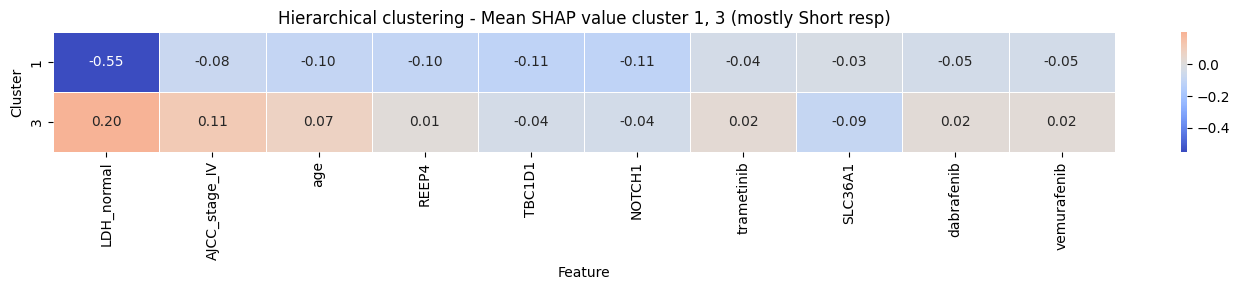

In [51]:
subset_clusters = [1, 3]

plot_heatmap_clusters(
    sv_df, cluster_labels_hier, top_k=10, 
    title='Hierarchical clustering - Mean SHAP value cluster 1, 3 (mostly Short resp)',
    subset_clusters=subset_clusters
)

In [52]:
subset_clusters = [0, 2]
explain_target = 1

maskA = (cluster_labels_hier == subset_clusters[0]) & (y_arr == explain_target)
maskB = (cluster_labels_hier == subset_clusters[1]) & (y_arr == explain_target)

pos_A = np.where(maskA)[0]
pos_B = np.where(maskB)[0]

cluster_means = sv_df.groupby("cluster").mean()
cluster_means = cluster_means.loc[subset_clusters]
top_features = cluster_means.std(axis=0).nlargest(10).index

x_display = pd.get_dummies(x).reset_index(drop=True)
valid_features = [f for f in top_features if f in x_display.columns]
print(x_display.iloc[pos_A][valid_features])
print(x_display.iloc[pos_B][valid_features])


     SLC36A1  trametinib  dabrafenib  vemurafenib    NOTCH1      STX2  \
1   2.153561           0           0            1  3.629710  2.604217   
2   1.903797           0           0            1  2.587868  3.082058   
7   1.608639           0           0            1  3.428465  2.070689   
9   2.172463           0           0            1  2.503283  2.076454   
14  1.906188           0           0            1  2.004744  3.591494   
19  2.315014           0           0            1  2.711182  2.600262   
23  1.247663           0           0            1  3.239028  2.375626   
24  1.717924           0           0            1  3.579790  2.751674   
25  2.145117           0           0            1  3.038704  2.817965   
44  1.797837           0           0            1  0.612360  3.382255   
45  1.904396           0           0            1  2.593172  2.468046   
59  2.329961           0           1            0  3.403721  1.948366   
63  1.588222           0           0            1  

In [53]:
subset_clusters = [1, 3]
explain_target = 0

maskA = (cluster_labels_hier == subset_clusters[0]) & (y_arr == explain_target)
maskB = (cluster_labels_hier == subset_clusters[1]) & (y_arr == explain_target)

pos_A = np.where(maskA)[0]
pos_B = np.where(maskB)[0]

cluster_means = sv_df.groupby("cluster").mean()
cluster_means = cluster_means.loc[subset_clusters]
top_features = cluster_means.std(axis=0).nlargest(10).index

x_display = pd.get_dummies(x).reset_index(drop=True)
valid_features = [f for f in top_features if f in x_display.columns]
print(x_display.iloc[pos_A][valid_features])
print(x_display.iloc[pos_B][valid_features])


    LDH_normal  AJCC_stage_IV  age     REEP4    TBC1D1    NOTCH1  trametinib  \
0        False           True   26  3.985531  3.450505  3.070871           0   
5        False           True   51  5.014304  3.185989  3.278240           0   
15       False           True   47  4.597446  2.656128  4.120365           0   
17       False           True   36  3.745731  3.177746  3.050507           0   
18       False           True   69  5.011666  2.964098  5.938888           0   
28       False           True   62  4.389733  3.106629  3.295093           0   
29       False           True   48  3.822185  3.041833  4.237081           0   
34       False           True   44  3.975538  3.392423  2.678992           0   
35       False           True   39  4.708735  3.115127  3.578943           0   
37       False           True   52  4.334745  4.731274  3.602243           0   
38       False           True   35  3.753683  4.259467  2.998315           0   
39       False           True   31  3.83

## Subgroups analysis: Skope-rules

In [54]:
from imodels import SkopeRulesClassifier

# One-hot encode categoricals so SkopeRules gets numeric input;
# get_dummies keeps names like "m_stage_M1B" which remain clinically readable.
x_encoded = pd.get_dummies(x).reset_index(drop=True)
feature_cols = list(x_encoded.columns)
x_raw = x_encoded.values.astype(float)

print("=" * 70)
print("Skope-Rules — decision rules per hierarchical cluster (raw features)")
print("=" * 70)

for k in range(n_clusters_hier):
    binary_target = (cluster_labels_hier == k).astype(int)
    n_pos = int(binary_target.sum())

    sr = SkopeRulesClassifier(
        precision_min=0.70,      # was 0.5 — catch more rules
        recall_min=0.55,         # was 0.5 — catch more rules
        random_state=42,
        n_estimators=50,         # was 10 — much more diverse rules
        max_depth=3,             # keep
        max_depth_duplication=2, # was 2 — allow slightly more overlap
        # max_features=0.8,        # add this — feature diversit
    )
    sr.fit(x_raw, binary_target, feature_names=feature_cols)

    counts = pd.Series(y_arr[cluster_labels_hier == k]).value_counts().sort_index()
    short, long_ = counts.get(0, 0), counts.get(1, 0)
    print(f"\nCluster {k}  ({n_pos} patients — {short} Short resp, {long_} Long resp)")
    print("-" * 50)

    if sr.rules_:
        for rule, (prec, rec, n) in sr.rules_:
            print(f"  IF {rule}")
            print(f"     → precision={prec:.2f}  recall={rec:.2f}  support={n}")
    else:
        print("  No rules found (try lowering precision_min / recall_min)")

Skope-Rules — decision rules per hierarchical cluster (raw features)

Cluster 0  (23 patients — 7 Short resp, 16 Long resp)
--------------------------------------------------
  IF AJCC_stage_IV > 0.5 and LDH_normal > 0.5 and M_stage_M1C <= 0.5
     → precision=1.00  recall=0.86  support=1
  IF M_stage_M1A > 0.5
     → precision=1.00  recall=0.68  support=11
  IF MIR23B <= 0.2205 and M_stage_M1A <= 0.5 and M_stage_M1B > 0.5
     → precision=1.00  recall=0.67  support=1
  IF ALDH5A1 <= 2.25133 and REEP4 > 3.48749 and TBC1D1 > 3.97324
     → precision=0.75  recall=0.60  support=1

Cluster 1  (19 patients — 17 Short resp, 2 Long resp)
--------------------------------------------------
  IF AJCC_stage_IV > 0.5 and LDH_elevated > 0.5 and M_stage_M1A <= 0.5
     → precision=1.00  recall=1.00  support=2
  IF LDH_elevated > 0.5 and M_stage_M1A <= 0.5 and PGM3 <= 4.07878
     → precision=1.00  recall=1.00  support=1
  IF CXCR5 <= 0.60794 and LDH_normal <= 0.5 and M_stage_M1C > 0.5
     → precisi